<a href="https://colab.research.google.com/github/grippo-droid/Machine_Learning/blob/main/Simple_Linear_Regression_Practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

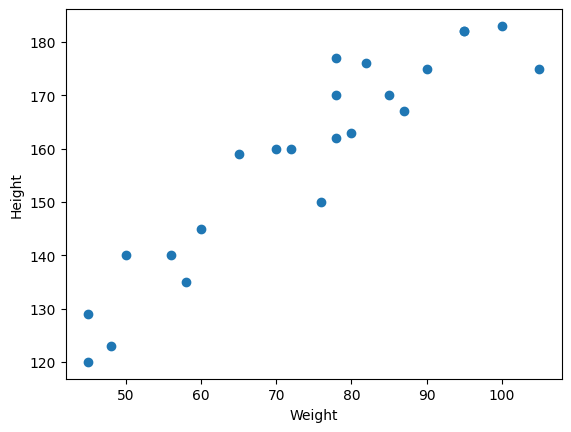

In [5]:
##scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [6]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


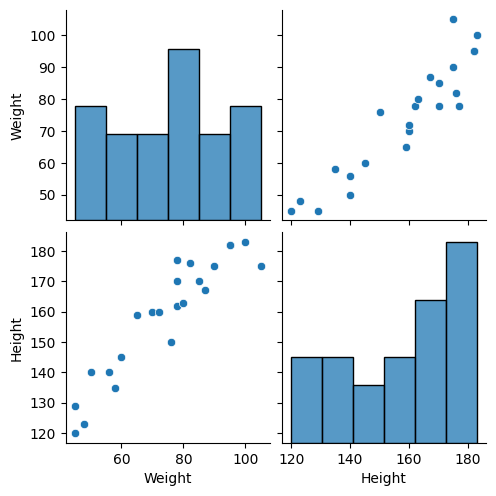

In [7]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [9]:
## Independent and dependent features
X=df[['Weight']] ### independent features should be data frame or 2 dimesnional array
y=df['Height'] ## this variiable or dependent/output can be in series or 1d array


In [10]:
X_series=df['Weight']
np.array(X_series).shape

(23,)

In [11]:
np.array(y).shape

(23,)

In [12]:
## Train Test Split
from sklearn.model_selection import train_test_split


In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

ranndom state gets the data in the same order as in the lecture

In [14]:
## Standardization
from sklearn.preprocessing import StandardScaler

as the units of the dependent and independent features are different and also independent features can have the units like kgs this will make it slower to get to the global minima in the gradient descent so we try to standardize the independent feature only the independent feature not the output feature using the z-score to make the MEAN=0 and STANDARD DEVIATION=1 thus making the data in proper format using the formula for the z=score 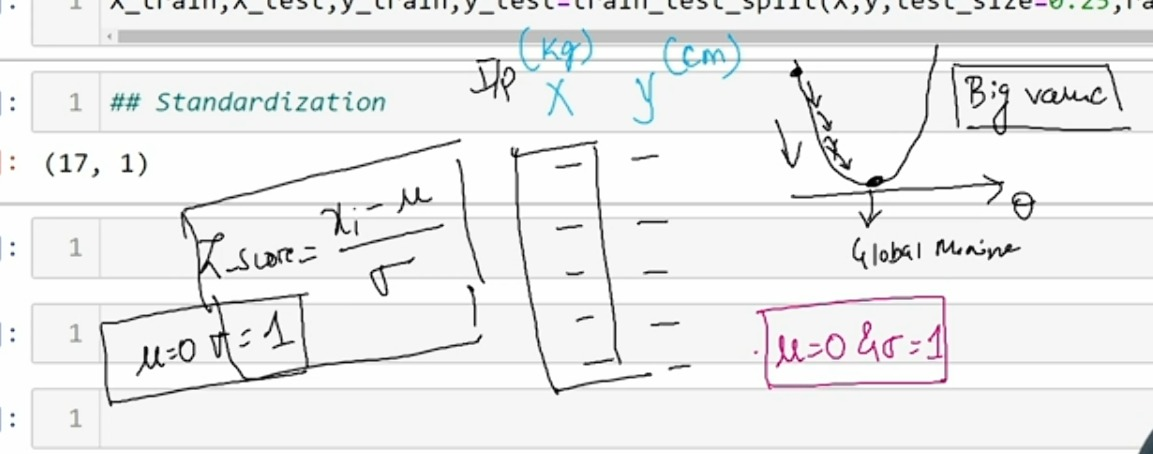

In [15]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [16]:
X_test=scaler.transform(X_test)

for the test data we dont use the fit_tranform because it will then calculate the new mean and the standard deviation dedicated for the test data and we dont want that we want the test data to use the same mean and same standard deviation as that of the train data thus we dont want the train data to know anything about the test data to prevent the data leakage

In [17]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [18]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [19]:
regression=LinearRegression(n_jobs=-1)

In [20]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

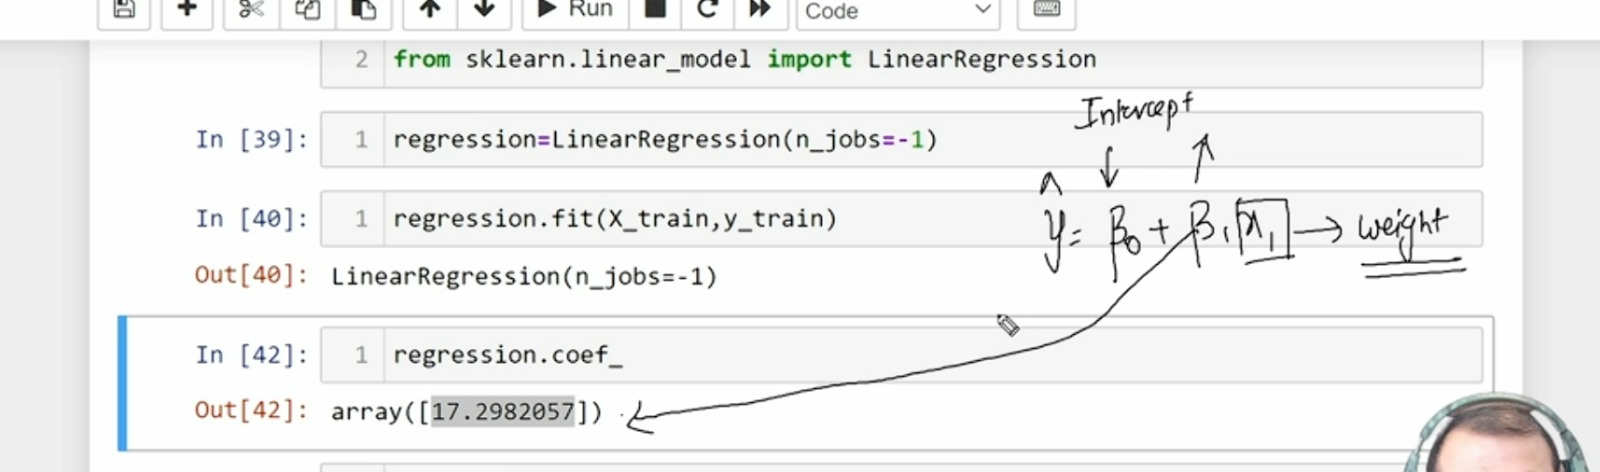

In [21]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [17.2982057]
Intercept: 156.47058823529412


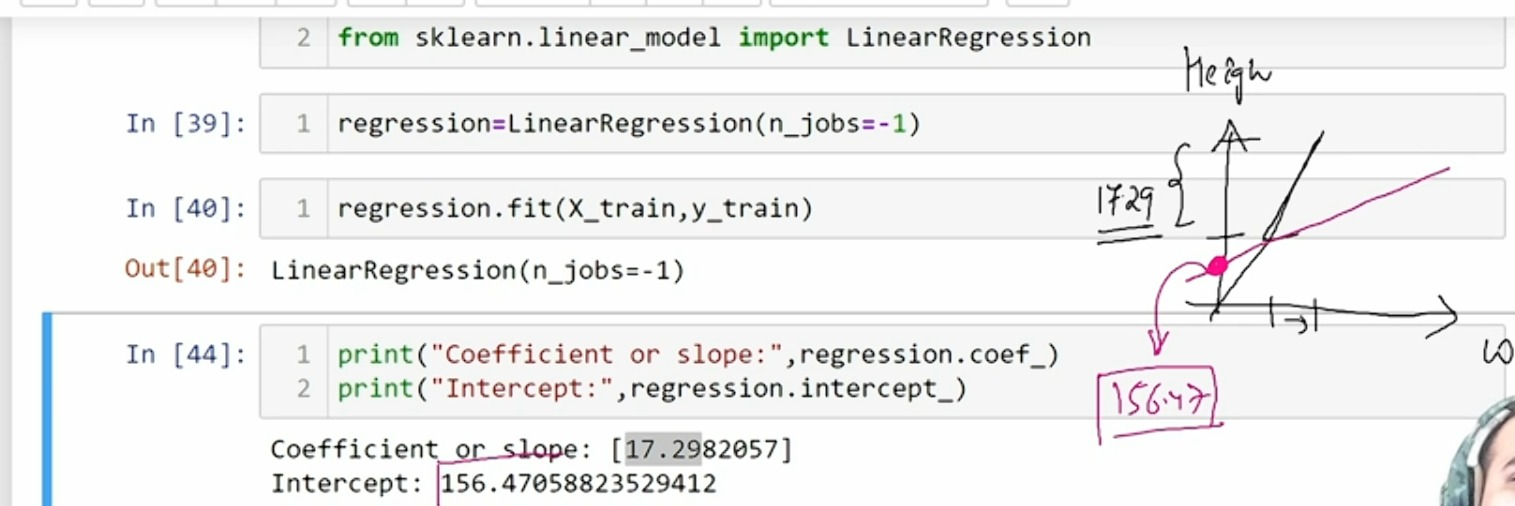

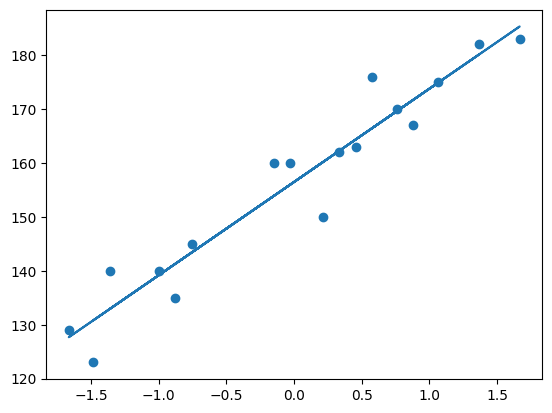

In [22]:
## plot Training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =156.470 + 17.29(X_test)

In [23]:
## Prediction for test data
y_pred=regression.predict(X_test)

In [24]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [25]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


## R square
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [26]:
from sklearn.metrics import r2_score

In [27]:
score=r2_score(y_test,y_pred)
print(score)

0.7360826717981276


73.60% accuracy as per R square test

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [28]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

67.01% accuracy as per Adjusted R-squared test

In [29]:
## OLS Linear Regression
import statsmodels.api as sm

In [30]:
model=sm.OLS(y_train,X_train).fit()

In [31]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [32]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 19 Mar 2026   Prob (F-statistic):                       0.664
Time:                        17:39:10   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [33]:
## Prediction For new data
regression.predict(scaler.transform([[72]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])

Here we need to perfrom standardization on the weight scaler transform([[72]]) before in order to get the proper output